In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/SDG_15_Life_on_Land_Dataset.csv', index_col=0)
df.head()

,WaterQualityIndex,ClimateChangeImpactScore,LandUseChange,InvasiveSpeciesCount,ConservationFunding,EcoTourismImpact,ForestCoverChange,SoilQualityIndex,WaterUsage,RenewableEnergyUsage,CarbonEmissionLevels,AgriculturalIntensity,HabitatConnectivity,SpeciesReintroductionEfforts,PollinatorDiversity,BiodiversityHealthIndex
Year,,,,,,,,,,,,,,,,
2010,35,7.542535,6.630073,39,46,1.193810,0.032204,70,33,13,22,1.419332,1.671324,9.311312,0.270434,0.194332
2010,13,1.617642,6.477132,45,18,8.484718,-4.803485,69,67,57,63,3.048794,5.815305,4.698086,0.729916,0.525779
2010,10,0.904817,9.069428,28,59,3.412444,-2.563852,72,85,37,46,7.863218,9.543694,2.080495,0.068508,0.684795
2010,36,7.060190,7.061932,37,88,9.718453,3.425382,64,85,96,60,1.065595,4.938359,2.192657,0.145065,0.926146
2010,24,8.439246,4.504786,41,88,9.118186,-1.295086,12,0,85,61,9.785784,2.114002,7.405189,0.809798,0.126345


In [4]:
df.shape

(1000, 16)

In [5]:
X = df.drop('BiodiversityHealthIndex', axis=1)
y = df['BiodiversityHealthIndex']

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

In [9]:
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y,
                                                    test_size=0.20,
                                                    random_state=1,
                                                    shuffle=False)

In [12]:
from sklearn.linear_model import Lasso

In [13]:
lasso = Lasso(alpha=0.01)

In [14]:
lasso.fit(X_train, y_train)

Lasso(alpha=0.01)

In [15]:
intercept = float(lasso.intercept_)

In [16]:
coeff = pd.DataFrame(lasso.coef_, X.columns, columns=['Coefficient'])

In [17]:
print("Intercept:", float(intercept))

Intercept: 0.49906676138993555


In [18]:
coeff

,Coefficient
WaterQualityIndex,0.000000
ClimateChangeImpactScore,-0.000513
LandUseChange,0.001296
InvasiveSpeciesCount,0.002664
ConservationFunding,-0.004523
EcoTourismImpact,-0.010264
ForestCoverChange,-0.004398
SoilQualityIndex,0.000000
WaterUsage,0.000000
RenewableEnergyUsage,0.000000


In [19]:
from sklearn.linear_model import LinearRegression, Ridge
X_subset = df.drop(['BiodiversityHealthIndex'], axis=1)  
X_subset_scaled = scaler.fit_transform(X_subset)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_subset_scaled,
                                                        y,
                                                        test_size=0.20,
                                                        random_state=1,
                                                        shuffle=False)

lm_subset = LinearRegression()

lm_all = LinearRegression()

ridge = Ridge()

lm_subset.fit(X_train2, y_train2)
lm_all.fit(X_train, y_train)
ridge.fit(X_train, y_train)

Ridge()

In [20]:
from sklearn import metrics

In [21]:
train_lm_subset = lm_subset.predict(X_train2)
train_lm_all = lm_all.predict(X_train)
train_ridge = ridge.predict(X_train)
train_lasso = lasso.predict(X_train)

In [22]:
test_lm_subset = lm_subset.predict(X_test2)
test_lm_all = lm_all.predict(X_test)
test_ridge = ridge.predict(X_test)
test_lasso = lasso.predict(X_test)

In [23]:
results_dict = {'Training MSE':
                    {
                        "Least Squares, Subset": metrics.mean_squared_error(y_train2, train_lm_subset),
                        "Least Squares, All": metrics.mean_squared_error(y_train, train_lm_all),
                        "Ridge": metrics.mean_squared_error(y_train, train_ridge),
                        "LASSO": metrics.mean_squared_error(y_train, train_lasso)
                    },
                    'Test MSE':
                    {
                        "Least Squares, Subset": metrics.mean_squared_error(y_test2, test_lm_subset),
                        "Least Squares, All": metrics.mean_squared_error(y_test, test_lm_all),
                        "Ridge": metrics.mean_squared_error(y_test, test_ridge),
                        "LASSO": metrics.mean_squared_error(y_test, test_lasso)
                    }
                }

In [24]:
results_df = pd.DataFrame(data=results_dict)

In [25]:
results_df

,Training MSE,Test MSE
"Least Squares, Subset",0.081708,0.079791
"Least Squares, All",0.081708,0.079791
Ridge,0.081708,0.079787
LASSO,0.082665,0.078657


In [26]:
train_plot = pd.concat([y_train, pd.Series(y_test.iloc[0], index=['Next Time Point'])])

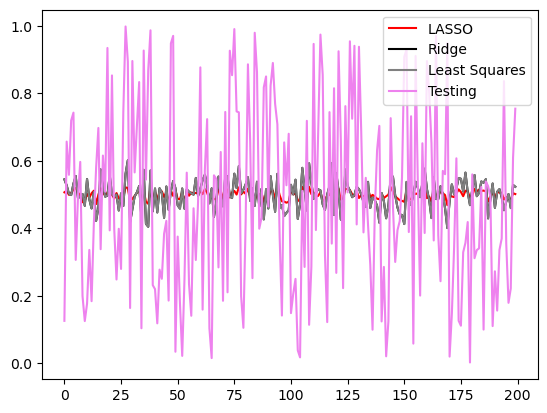

In [28]:
plt.plot(np.arange(len(y_test)), lasso.predict(X_test), label='LASSO',color='red')
plt.plot(np.arange(len(y_test)), ridge.predict(X_test), label='Ridge', color='black')
plt.plot(np.arange(len(y_test)), lm_all.predict(X_test), label='Least Squares', color='grey')
plt.plot(np.arange(len(y_test)), y_test.values, label='Testing', color='violet')
plt.legend()

plt.show()